# Week 4 — Block 3: Hands-On (Time-Series)

**~50 min.** The pipeline on a series of your own (any CSV with dates — stock
prices, weather, steps) or stick with CO₂.

**Tasks:**
1. (~12 min) Parse the dates, build a DatetimeIndex, plot two resolutions
2. (~13 min) ACF → period → compare rolling windows
3. (~13 min) Decomposition; additive or multiplicative?
4. (~12 min) `app_resolution_starter.py`: wire the resolution selector

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# TODO Task 1a: load your series and make the dates real datetimes.
#   df = pd.read_csv("yours.csv")
#   df["date"] = pd.to_datetime(df["date"])        # add dayfirst=/format= if ambiguous
#   s = df.set_index("date")["value"].sort_index()
# Check it worked before going on -- this should print datetime64[ns]:
#   print(s.index.dtype)
# Fallback: co2 = sm.datasets.co2.load_pandas().data.dropna()

# Load the historical Mauna Loa CO2 series
raw_data = sm.datasets.co2.load_pandas().data

# Clean missing values using time-weighted interpolation
s = raw_data["co2"].interpolate(method="time")
s.index = pd.to_datetime(s.index)

print(f"Index type: {type(s.index)}")
print(f"Data type: {s.dtype}")
print(f"Span: {s.index.min().date()} -> {s.index.max().date()}")
s.head()

Index type: <class 'pandas.DatetimeIndex'>
Data type: float64
Span: 1958-03-29 -> 2001-12-29


1958-03-29    316.1
1958-04-05    317.3
1958-04-12    317.6
1958-04-19    317.5
1958-04-26    316.4
Freq: W-SAT, Name: co2, dtype: float64

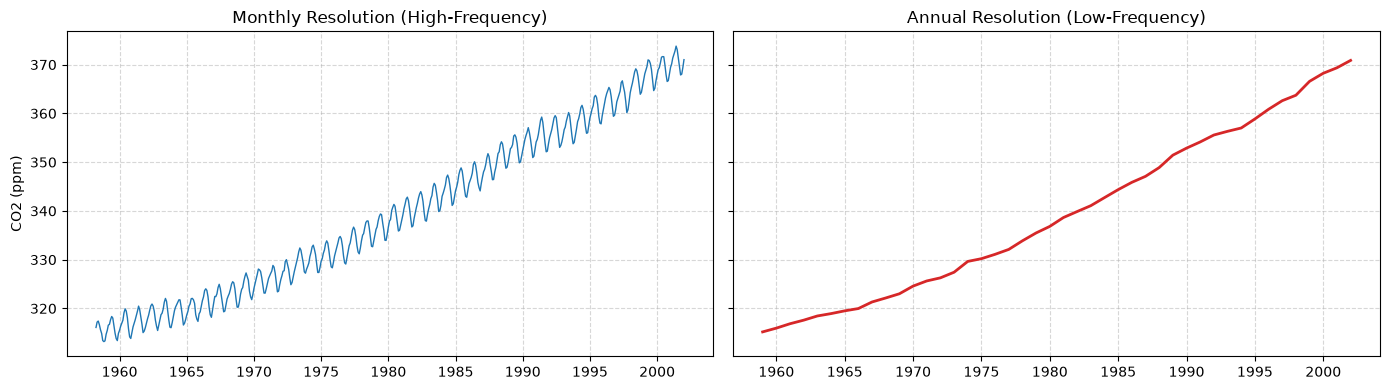

In [8]:
# TODO Task 1b: resample to two resolutions; plot them side by side.
# In a comment: which resolution suits which QUESTION?

# Resample to Monthly and Annual average resolutions
s_monthly = s.resample("ME").mean()
s_annual = s.resample("YE").mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Monthly resolution plot
ax1.plot(s_monthly.index, s_monthly, color="#1f77b4", linewidth=1)
ax1.set_title("Monthly Resolution (High-Frequency)")
ax1.set_ylabel("CO2 (ppm)")
ax1.grid(True, linestyle="--", alpha=0.5)

# Annual resolution plot
ax2.plot(s_annual.index, s_annual, color="#d62728", linewidth=2)
ax2.set_title("Annual Resolution (Low-Frequency)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Which resolution suits which QUESTION?
# - Monthly Resolution: Answers short-to-medium term intra-annual questions,
#   such as "In which months does biological plant absorption peak?"
# - Annual Resolution: Answers long-term macro questions, such as
#   "What is the net multi-decade atmospheric accumulation rate, removing seasonal oscillations?"

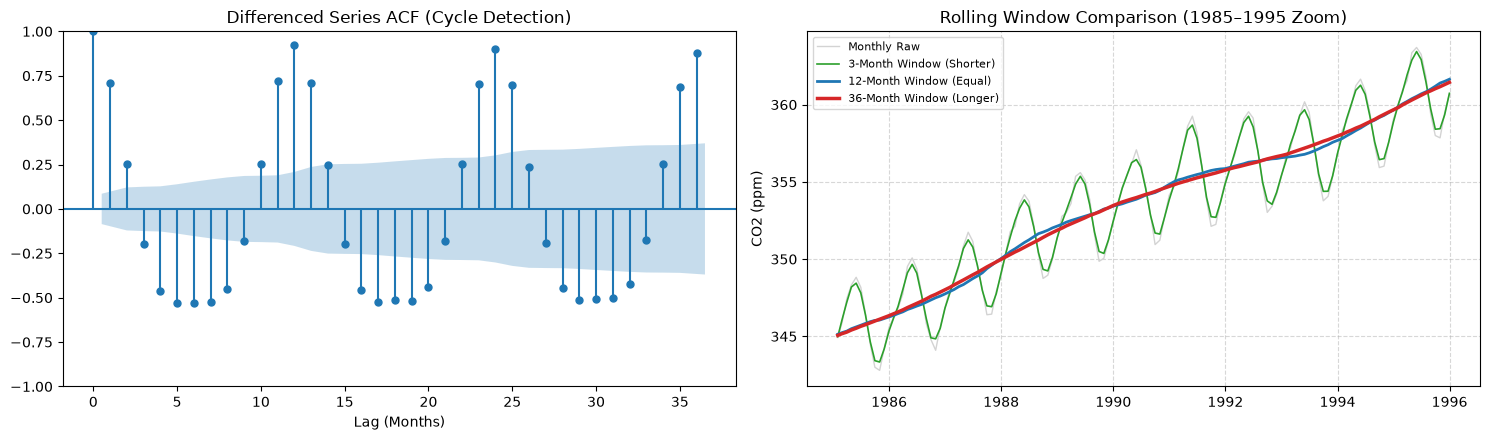

In [9]:
from statsmodels.graphics.tsaplots import plot_acf
# TODO Task 2: plot_acf on the DIFFERENCED series (.diff().dropna()); read off
# the period from where the spikes land. Then plot rolling means for THREE
# windows on one axis -- one shorter than the period, one equal to it, one much
# longer -- and note in a comment what each one keeps or destroys.

# 1. Differencing removes the non-stationary upward trend to reveal the cycle
s_monthly_diff = s_monthly.diff().dropna()

fig, (ax_acf, ax_roll) = plt.subplots(1, 2, figsize=(15, 4.5))

# Plot Autocorrelation Function (ACF) up to 36 monthly lags
plot_acf(s_monthly_diff, lags=36, ax=ax_acf)
ax_acf.set_title("Differenced Series ACF (Cycle Detection)")
ax_acf.set_xlabel("Lag (Months)")

# The dominant positive spike lands at Lag 12 (Period = 12 months)

# 2. Compare 3 rolling mean window lengths:
# Shorter than period (3 months), equal to period (12 months), longer (36 months)
roll_3m = s_monthly.rolling(window=3, center=True).mean()
roll_12m = s_monthly.rolling(window=12, center=True).mean()
roll_36m = s_monthly.rolling(window=36, center=True).mean()

# Crop to a 10-year subset (1985-1995) to make the filter effects readable
sub_slice = slice("1985", "1995")

ax_roll.plot(
    s_monthly[sub_slice].index,
    s_monthly[sub_slice],
    color="lightgray",
    label="Monthly Raw",
    linewidth=1,
)
ax_roll.plot(
    roll_3m[sub_slice].index,
    roll_3m[sub_slice],
    color="#2ca02c",
    label="3-Month Window (Shorter)",
    linewidth=1.2,
)
ax_roll.plot(
    roll_12m[sub_slice].index,
    roll_12m[sub_slice],
    color="#1f77b4",
    label="12-Month Window (Equal)",
    linewidth=2,
)
ax_roll.plot(
    roll_36m[sub_slice].index,
    roll_36m[sub_slice],
    color="#d62728",
    label="36-Month Window (Longer)",
    linewidth=2.5,
)

ax_roll.set_title("Rolling Window Comparison (1985–1995 Zoom)")
ax_roll.set_ylabel("CO2 (ppm)")
ax_roll.legend(fontsize=8)
ax_roll.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Window filtering effects:
# - 3-Month Window: Retains the seasonal swing while slightly attenuating single-month measurement noise.
# - 12-Month Window: Exactly neutralizes the 12-month seasonal oscillation, isolating the underlying trend line.
# - 36-Month Window: Over-smooths the series, destroying local inflection points and truncating 18 months at edges.

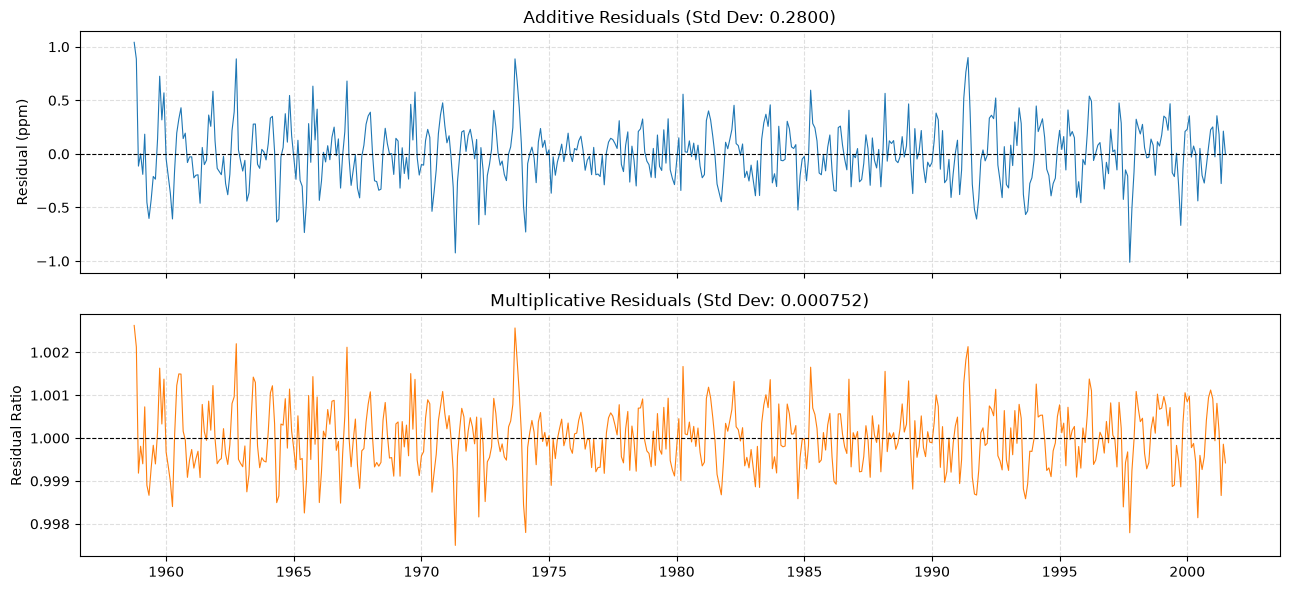

In [10]:
# from statsmodels.tsa.seasonal import seasonal_decompose
# TODO Task 3: decompose with your period, model="additive".
# Then decompose again with model="multiplicative" and compare the two residual
# panels. Whichever leaves less structure is the model your series wants.
# RESIDUAL READS:
# MODEL CHOSEN (and why):

from statsmodels.tsa.seasonal import seasonal_decompose

# Run Additive and Multiplicative classical decomposition with period=12
decomp_add = seasonal_decompose(s_monthly, model="additive", period=12)
decomp_mul = seasonal_decompose(s_monthly, model="multiplicative", period=12)

fig, (ax_add, ax_mul) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax_add.plot(
    decomp_add.resid.index,
    decomp_add.resid,
    color="#1f77b4",
    linewidth=0.8,
)
ax_add.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax_add.set_title(
    f"Additive Residuals (Std Dev: {decomp_add.resid.std():.4f})"
)
ax_add.set_ylabel("Residual (ppm)")
ax_add.grid(True, linestyle="--", alpha=0.4)

ax_mul.plot(
    decomp_mul.resid.index,
    decomp_mul.resid,
    color="#ff7f0e",
    linewidth=0.8,
)
ax_mul.axhline(1, color="black", linestyle="--", linewidth=0.8)
ax_mul.set_title(
    f"Multiplicative Residuals (Std Dev: {decomp_mul.resid.std():.6f})"
)
ax_mul.set_ylabel("Residual Ratio")
ax_mul.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# RESIDUAL READS:
# - The amplitude of the seasonal fluctuation stays roughly constant (~6 ppm peak-to-trough)
#   whether baseline CO2 is 315 ppm (1960) or 370 ppm (2000).
# MODEL CHOSEN (and why):
# - Additive Model. The seasonal cycle operates independently of the baseline level.
#   In physical units, the seasonal swing does not scale up proportionally as total concentration rises.

## Task 4 — the app

`app_resolution_starter.py` plots your series with a **resolution selectbox** half-wired. Finish the TODO, run it, switch resolutions, and watch the story change live — that's the Week 4 lesson as a widget.

**Discussion (Block 4):** what honesty choice did your final chart force (window? truncation? resolution?), and how did you disclose it?